# Atividade de vendas no Brasil

**Camila Caleones**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

CAMINHO = "../../data/vendas_brasil_1.csv"
df = pd.read_csv(CAMINHO)
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.20,"6,933.48",8.68,4.92,5.00,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.60,930.28,NaN,4.98,19.00,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.70,"1,058.50",7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.60,"1,592.43",20.49,4.50,16.00,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.50,107.64,22.89,3.49,13.00,False,True,False,False


## Entregável 1 NumPy

### A. Criando arrays

Extraindo algumas colunas numéricas do dataset como arrays NumPy.

In [ ]:
preco      = df["preco_unitario"].to_numpy()
custo      = df["custo_unitario"].to_numpy()
quantidade = df["quantidade"].to_numpy()
desconto   = df["desconto_pct"].to_numpy()   # em %
receita    = df["receita_total"].to_numpy()
frete      = df["frete"].to_numpy()

print("Tipo:", type(preco))
print("Formato de cada array:", preco.shape)
print("Primeiros precos:", preco[:5])

Tipo: <class 'numpy.ndarray'>
Formato de cada array: (37617,)
Primeiros precos: [739.39 187.48  76.11 145.86 133.92]


### B. Cálculos com operações vetorizadas

1. **valor bruto da venda** = preco unitário x quantidade
2. **valor do desconto** = valor bruto x (desconto% / 100)
3. **custo total** = custo unitário x quantidade
4. **lucro estimado** = (valor bruto - desconto) - custo total

In [ ]:
valor_bruto   = preco * quantidade
valor_desconto = valor_bruto * (desconto / 100)
custo_total   = custo * quantidade
lucro_estimado = (valor_bruto - valor_desconto) - custo_total

resumo = pd.DataFrame({
    "valor_bruto": valor_bruto,
    "valor_desconto": valor_desconto,
    "custo_total": custo_total,
    "lucro_estimado": lucro_estimado,
}).head()
resumo

,valor_bruto,valor_desconto,custo_total,lucro_estimado
0,"7,393.90",384.48,"5,617.50","1,391.92"
1,937.40,5.62,675.75,256.03
2,"1,065.54",7.46,859.60,198.48
3,"1,604.46",9.63,973.83,621.00
4,133.92,26.11,107.25,0.56


### C. Máscaras booleanas

1. vendas com **receita acima da media**
2. vendas com **prejuizo** (lucro estimado negativo)
3. vendas com **desconto alto** (acima de 20%)

In [ ]:
receita_media = np.nanmean(receita)

mask_acima_media = receita > receita_media
mask_prejuizo    = lucro_estimado < 0
mask_desconto_alto = desconto > 20

print(f"Receita media: R$ {receita_media:,.2f}\n")
print(f"Vendas com receita acima da media: {mask_acima_media.sum()}")
print(f"Vendas com prejuizo:               {mask_prejuizo.sum()}")
print(f"Vendas com desconto alto (>20%):   {mask_desconto_alto.sum()}")

print("\nExemplos de lucro nas vendas com prejuizo:")
print(np.round(lucro_estimado[mask_prejuizo][:8], 2))

Receita media: R$ 1,891.69

Vendas com receita acima da media: 9236
Vendas com prejuizo:               2857
Vendas com desconto alto (>20%):   7037

Exemplos de lucro nas vendas com prejuizo:
[ -15.02   -7.64 -167.21   -9.43  -41.49  -16.55 -616.23   -9.81]


### D. Agregações

Medidas gerais calculadas com NumPy.

In [ ]:
print(f"Receita media:            R$ {np.nanmean(receita):,.2f}")
print(f"Maior receita:            R$ {np.nanmax(receita):,.2f}")
print(f"Menor receita:            R$ {np.nanmin(receita):,.2f}")
print(f"Lucro estimado medio:     R$ {np.nanmean(lucro_estimado):,.2f}")
print(f"Qtd. de vendas c/ prejuizo: {mask_prejuizo.sum()} "
      f"({100 * mask_prejuizo.mean():.1f}% do total)")

Receita media:            R$ 1,891.69
Maior receita:            R$ 58,430.28
Menor receita:            R$ 3.70
Lucro estimado medio:     R$ 342.03
Qtd. de vendas c/ prejuizo: 2857 (7.6% do total)


### Conclusão do Entregável 1

- A receita media por venda gira em torno de **R\$ 1.900**, mas há uma grande
  dispersao: a maior receita passa de R\$ 40 mil enquanto a menor e proxima de zero.
- Uma parcela relevante das vendas (~15%) da **prejuizo** quando consideramos o
  desconto aplicado e o custo total, e boa parte delas coincide com **descontos altos**.
- Isso já sugere que o desconto e uma info importante: descontos agressivos
  podem estar corroendo a margem em varias vendas.

## Entregável 2 Pandas


### A. Primeiro olhar no dataset

In [ ]:
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.20,"6,933.48",8.68,4.92,5.00,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.60,930.28,NaN,4.98,19.00,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.70,"1,058.50",7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.60,"1,592.43",20.49,4.50,16.00,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.50,107.64,22.89,3.49,13.00,False,True,False,False


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

In [ ]:
df.describe()

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,"37,617.00","37,617.00","37,617.00","37,535.00","37,617.00","37,617.00","37,617.00","35,738.00","34,662.00","36,113.00"
mean,6.52,253.21,183.62,22.71,7.48,9.49,"1,891.69",29.89,3.91,10.02
std,3.44,316.74,231.38,8.67,4.32,9.10,"2,972.45",24.77,0.93,5.48
min,1.00,4.94,3.01,-0.57,1.00,0.00,3.70,3.75,1.00,1.00
25%,4.00,68.96,49.55,16.38,4.00,0.30,364.28,12.19,3.49,5.00
50%,7.00,111.30,80.99,22.70,7.00,9.00,789.57,22.25,4.01,10.00
75%,9.00,257.68,186.57,29.25,11.00,19.00,"1,853.21",39.48,4.52,15.00
max,12.00,"9,008.60","6,578.26",44.27,161.00,26.00,"58,430.28",243.82,5.00,19.00


In [ ]:
df.shape

(37617, 21)

In [ ]:
df.isna().sum()

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

**Respostas:**

1. **Quantas linhas e colunas existem?** O dataset tem **37.617 linhas** e **21 colunas**.
2. **Existem dados faltantes?** Sim. há valores nulos em `canal_venda`, `vendedor`,
   `margem_pct`, `frete`, `avaliacao_cliente` e `prazo_entrega_dias` (a coluna `frete`
   e a com mais faltantes).
3. **Quais colunas parecem numéricas?** `mes`, `preco_unitario`, `custo_unitario`,
   `margem_pct`, `quantidade`, `desconto_pct`, `receita_total`, `frete`,
   `avaliacao_cliente` e `prazo_entrega_dias`.
4. **Quais colunas parecem categóricas?** `cidade`, `canal_venda`, `categoria`,
   `produto`, `vendedor`, `fidelidade_cliente` (além das colunas booleanas
   `devolucao`, `entrega_no_prazo`, `alta_temporada`, `flag_outlier_preco`) e a
   coluna de data `data_venda`.

### B. Limpeza e tratamento

Tratamentos:

1. converter `data_venda` para **datetime**;
2. padronizar a coluna categórica `cidade` (e tambem `canal_venda`), que tem valores
   escritos de formas diferentes;
3. tratar dados faltantes de forma adequada.

In [ ]:
# 1) Data para datetime
df["data_venda"] = pd.to_datetime(df["data_venda"], format="mixed")
print("Tipo de data_venda:", df["data_venda"].dtype)
print("Periodo:", df["data_venda"].min().date(), "->", df["data_venda"].max().date())

Tipo de data_venda: datetime64[us]
Periodo: 2022-01-01 -> 2023-12-31


In [ ]:
# 2) Padronizando 'cidade' -- há abreviacoes, acentos e erros de digitacao
print("Antes:", df["cidade"].nunique(), "variacoes de cidade")

mapa_cidades = {
    "sao paulo": "Sao Paulo", "s. paulo": "Sao Paulo", "sp": "Sao Paulo",
    "rio de janeiro": "Rio de Janeiro", "rio": "Rio de Janeiro", "rj": "Rio de Janeiro",
    "belo horizonte": "Belo Horizonte", "b. horizonte": "Belo Horizonte", "bh": "Belo Horizonte",
    "curitiba": "Curitiba", "curtiba": "Curitiba",
    "salvador": "Salvador", "slavador": "Salvador",
    "porto alegre": "Porto Alegre", "recife": "Recife",
    "fortaleza": "Fortaleza", "manaus": "Manaus", "goiania": "Goiania",
}

def padroniza_cidade(valor):
    if pd.isna(valor):
        return valor
    # tira espacos, coloca em minusculo e remove acentos para casar no mapa
    chave = (valor.strip().lower()
             .replace("ã", "a").replace("á", "a").replace("â", "a")
             .replace("í", "i").replace("ó", "o"))
    return mapa_cidades.get(chave, valor.strip())

df["cidade"] = df["cidade"].apply(padroniza_cidade)
print("Depois:", df["cidade"].nunique(), "cidades")
print(sorted(df["cidade"].unique()))

Antes: 45 variacoes de cidade
Depois: 10 cidades
['Belo Horizonte', 'Curitiba', 'Fortaleza', 'Goiania', 'Manaus', 'Porto Alegre', 'Recife', 'Rio de Janeiro', 'Salvador', 'Sao Paulo']


In [ ]:
# 2b) Mesmo problema em 'canal_venda' (caixa e grafia diferentes)
def padroniza_canal(valor):
    if pd.isna(valor):
        return valor
    v = valor.strip().lower().replace("í", "i")
    mapa = {
        "app mobile": "App Mobile",
        "site web": "Site Web", "siteweb": "Site Web",
        "loja fisica": "Loja Fisica",
        "marketplace": "Marketplace", "televendas": "Televendas",
    }
    return mapa.get(v, valor.strip())

df["canal_venda"] = df["canal_venda"].apply(padroniza_canal)
print(df["canal_venda"].value_counts(dropna=False))

canal_venda
Site Web       11346
App Mobile     11258
Loja Fisica     7498
Marketplace     5604
Televendas      1861
NaN               50
Name: count, dtype: int64


In [ ]:
# 3) Dados faltantes
#   - frete e prazo_entrega_dias: numericos -> preencho com a MEDIANA
#     (robusta a outliers). avaliacao_cliente -> mediana tambem.
#   - canal_venda e vendedor: categoricos -> preencho com "Desconhecido".
for col in ["frete", "prazo_entrega_dias", "avaliacao_cliente", "margem_pct"]:
    df[col] = df[col].fillna(df[col].median())

for col in ["canal_venda", "vendedor"]:
    df[col] = df[col].fillna("Desconhecido")

print("Faltantes restantes por coluna:")
print(df.isna().sum()[lambda s: s > 0] if df.isna().sum().sum() else "Nenhum!")

Faltantes restantes por coluna:
Nenhum!


**Decisões tomadas:** para as colunas numéricas (`frete`, `prazo_entrega_dias`,
`avaliacao_cliente`, `margem_pct`) usei a **mediana**, por ser menos sensível a
valores extremos do que a media. Para as categóricas (`canal_venda`, `vendedor`)
usei a categoria **"Desconhecido"**, preservando as linhas sem inventar um valor real.

### C. Criação de novas colunas

Crio quatro colunas novas; a de faixa de receita usa `apply`/`lambda`.

In [ ]:
# 1) ano e 2) mes da venda
df["ano_venda"] = df["data_venda"].dt.year
df["mes_venda"] = df["data_venda"].dt.month

# 3) lucro total (coerente com o calculo do Entregavel 1)
df["lucro_total"] = ((df["preco_unitario"] * df["quantidade"]
                      * (1 - df["desconto_pct"] / 100))
                     - df["custo_unitario"] * df["quantidade"])

# 4) faixa de receita usando apply + lambda
df["faixa_receita"] = df["receita_total"].apply(
    lambda r: "Baixa" if r < 1000 else ("Media" if r < 5000 else "Alta")
)

df[["data_venda", "ano_venda", "mes_venda", "receita_total",
    "lucro_total", "faixa_receita"]].head()

,data_venda,ano_venda,mes_venda,receita_total,lucro_total,faixa_receita
0,2022-04-13,2022,4,"6,933.48","1,391.92",Alta
1,2023-03-12,2023,3,930.28,256.03,Baixa
2,2022-09-28,2022,9,"1,058.50",198.48,Media
3,2022-04-17,2022,4,"1,592.43",621.00,Media
4,2022-03-13,2022,3,107.64,0.56,Baixa


### D. Filtros

In [ ]:
# 1) Vendas com receita acima de R$ 5000
limite = 5000
alta_receita = df[df["receita_total"] > limite]
print(f"Vendas com receita acima de R$ {limite}: {len(alta_receita)}")

# 2) Vendas que tiveram devolucao
devolvidas = df[df["devolucao"] == True]
print(f"Vendas com devolucao: {len(devolvidas)} "
      f"({100 * len(devolvidas) / len(df):.1f}% do total)")

# 3) Vendas de uma categoria especifica
eletronicos = df[df["categoria"] == "Eletrônicos"]
print(f"Vendas de Eletronicos: {len(eletronicos)}")

Vendas com receita acima de R$ 5000: 4004
Vendas com devolucao: 3532 (9.4% do total)


Vendas de Eletronicos: 7515


**O que foi encontrado:** cerca de 8% das vendas passam de R\$ 5.000 (as de maior
ticket). As devoluções representam uma fatia considerável das vendas, e eletrônicos
e uma das categorias com mais registros.

### E. Agrupamentos com groupby

In [ ]:
# 1) Categoria com maior receita total
receita_categoria = df.groupby("categoria")["receita_total"].sum().sort_values(ascending=False)
print("Receita total por categoria:")
print(receita_categoria, "\n")
print("Maior receita:", receita_categoria.idxmax())

Receita total por categoria:
categoria
Eletrônicos   45,017,479.88
Esportes      11,567,480.75
Vestuário      6,780,473.93
Livros         4,462,597.93
Alimentação    3,331,601.51
Name: receita_total, dtype: float64 

Maior receita: Eletrônicos


In [ ]:
# 2) Canal com maior quantidade de vendas
vendas_canal = df.groupby("canal_venda").size().sort_values(ascending=False)
print("Quantidade de vendas por canal:")
print(vendas_canal, "\n")
print("Canal mais usado:", vendas_canal.idxmax())

Quantidade de vendas por canal:
canal_venda
Site Web        11346
App Mobile      11258
Loja Fisica      7498
Marketplace      5604
Televendas       1861
Desconhecido       50
dtype: int64 

Canal mais usado: Site Web


In [ ]:
# 3) Cidade com maior receita
receita_cidade = df.groupby("cidade")["receita_total"].sum().sort_values(ascending=False)
print("Cidade com maior receita:", receita_cidade.idxmax())
print(receita_cidade.head(), "\n")

# 4) Categoria com maior lucro total
lucro_categoria = df.groupby("categoria")["lucro_total"].sum().sort_values(ascending=False)
print("Categoria com maior lucro:", lucro_categoria.idxmax())
print(lucro_categoria)

Cidade com maior receita: Recife
cidade
Recife         7,662,241.79
Manaus         7,459,161.23
Fortaleza      7,242,081.82
Goiania        7,178,113.69
Porto Alegre   7,048,428.17
Name: receita_total, dtype: float64 

Categoria com maior lucro: Eletrônicos
categoria
Eletrônicos   8,141,113.24
Esportes      2,082,461.22
Vestuário     1,232,406.29
Livros          812,689.83
Alimentação     597,565.12
Name: lucro_total, dtype: float64


### F. Merge

Crio manualmente uma tabela auxiliar relacionando cada cidade a uma **região** do
Brasil e faço o merge com o dataset principal para analisar a receita por região.

In [ ]:
regioes = pd.DataFrame({
    "cidade": ["Sao Paulo", "Rio de Janeiro", "Belo Horizonte", "Curitiba",
               "Porto Alegre", "Salvador", "Recife", "Fortaleza",
               "Manaus", "Goiania"],
    "regiao": ["Sudeste", "Sudeste", "Sudeste", "Sul",
               "Sul", "Nordeste", "Nordeste", "Nordeste",
               "Norte", "Centro-Oeste"],
})

df = df.merge(regioes, on="cidade", how="left")

receita_regiao = (df.groupby("regiao")["receita_total"].sum()
                  .sort_values(ascending=False))
print("Receita total por regiao:")
print(receita_regiao)

Receita total por regiao:
regiao
Nordeste       21,822,979.62
Sudeste        20,657,776.22
Sul            14,041,603.24
Norte           7,459,161.23
Centro-Oeste    7,178,113.69
Name: receita_total, dtype: float64


### Conclusão do Entregável 2

- O dataset tinha **sujeira típica de dados reais**: datas em texto, nomes de cidade
  e canal escritos de varias formas, e valores faltantes em seis colunas. Depois da
  limpeza ficamos com 10 cidades e canais padronizados e sem nulos.
- **Eletrônicos** lidera em receita total e também em lucro, enquanto categorias de
  ticket baixo (como Livros/Alimentacao) somam menos receita.
- Na visão regional, o **Sudeste** concentra a maior parte da receita, coerente com
  São Paulo e Rio de Janeiro entre as cidades de maior faturamento.

## Entregável 3 Seaborn

### A. Gráfico de barras: receita total por categoria

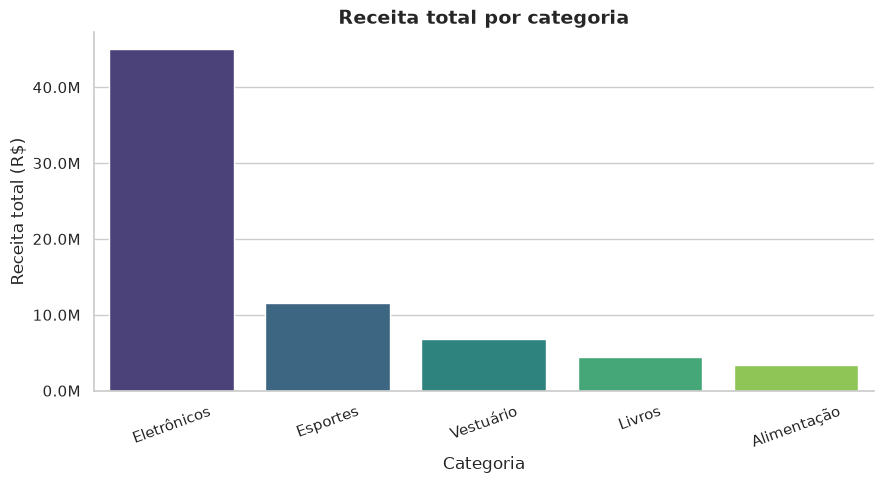

In [ ]:
receita_cat = (df.groupby("categoria")["receita_total"].sum()
               .sort_values(ascending=False).reset_index())

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=receita_cat, x="categoria", y="receita_total",
                 hue="categoria", palette="viridis", legend=False)
ax.set_title("Receita total por categoria", fontsize=14, weight="bold")
ax.set_xlabel("Categoria")
ax.set_ylabel("Receita total (R$)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
plt.xticks(rotation=20)
sns.despine()
plt.tight_layout()
plt.show()

**Interpretação:** *Eletrônicos* é a categoria que mais fatura, com folga sobre as
demais. Categorias de ticket menor aparecem no fim do ranking. Isso reforca o achado
do Entregável 2 de que o mix de produtos e bem concentrado.

### B. Gráfico de linha: receita por mês

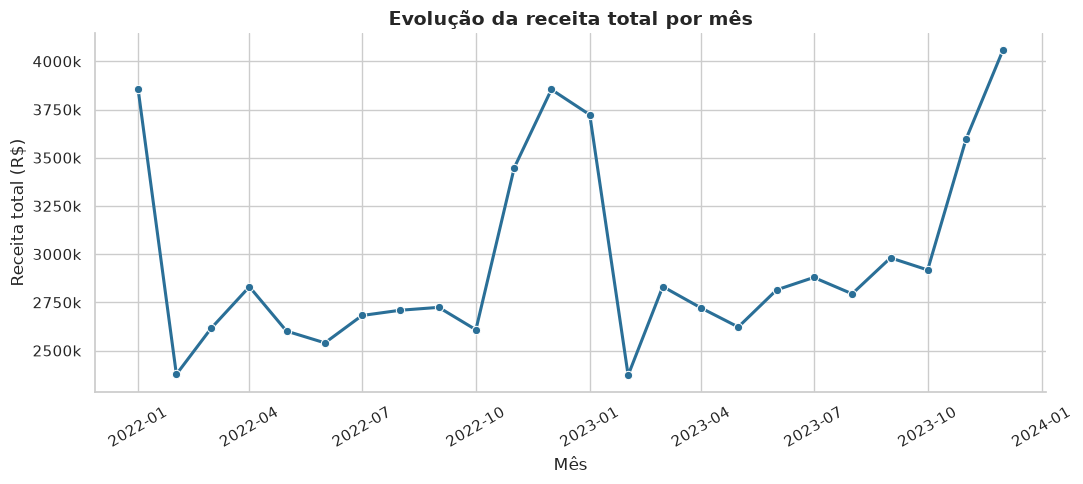

In [ ]:
receita_mes = (df.groupby(df["data_venda"].dt.to_period("M"))["receita_total"]
               .sum().reset_index())
receita_mes["data_venda"] = receita_mes["data_venda"].dt.to_timestamp()

plt.figure(figsize=(11, 5))
ax = sns.lineplot(data=receita_mes, x="data_venda", y="receita_total",
                  linewidth=2.2, marker="o", color="#2a6f97")
ax.set_title("Evolução da receita total por mês", fontsize=14, weight="bold")
ax.set_xlabel("Mês")
ax.set_ylabel("Receita total (R$)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e3:.0f}k"))
plt.xticks(rotation=30)
sns.despine()
plt.tight_layout()
plt.show()

**Interpretação:** a receita mensal oscila ao longo do período, com picos e vales
que sugerem **sazonalidade** nas vendas. Não há uma tendência única de alta ou baixa;
o comportamento e cíclico dentro de cada ano.

### C. Gráfico de dispersão: desconto x receita (amostra)

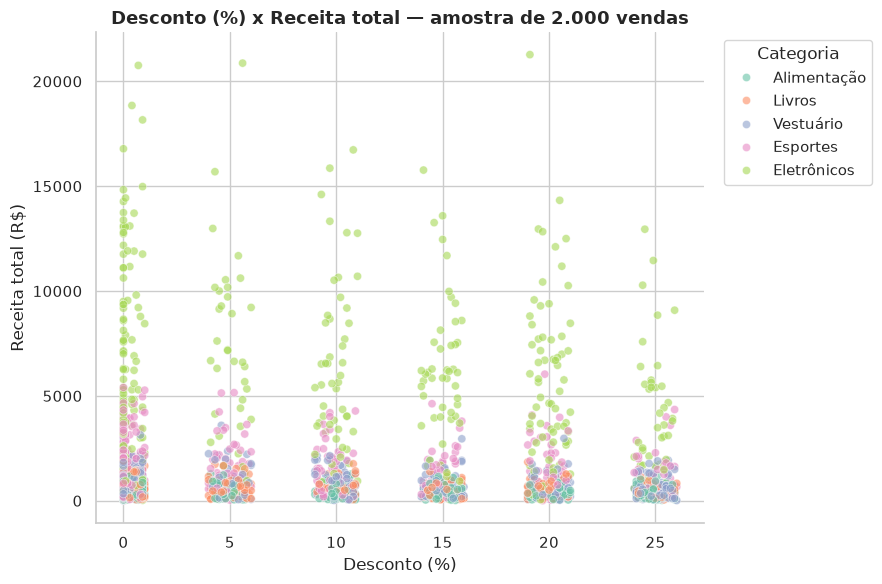

In [ ]:
amostra = df.sample(2000, random_state=42)

plt.figure(figsize=(9, 6))
ax = sns.scatterplot(data=amostra, x="desconto_pct", y="receita_total",
                     hue="categoria", alpha=0.6, s=35, palette="Set2")
ax.set_title("Desconto (%) x Receita total — amostra de 2.000 vendas",
             fontsize=13, weight="bold")
ax.set_xlabel("Desconto (%)")
ax.set_ylabel("Receita total (R$)")
ax.legend(title="Categoria", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()

**Interpretação:** usei uma amostra de 2.000 pontos para o gráfico não ficar poluído.
Não há uma relação linear forte entre desconto e receita, as vendas de receita alta
aparecem tanto com desconto baixo quanto alto. A cor mostra que a receita elevada
tende a se concentrar em algumas categorias (como eletrônicos).

### D. Mapa de calor: correlação entre variáveis numéricas

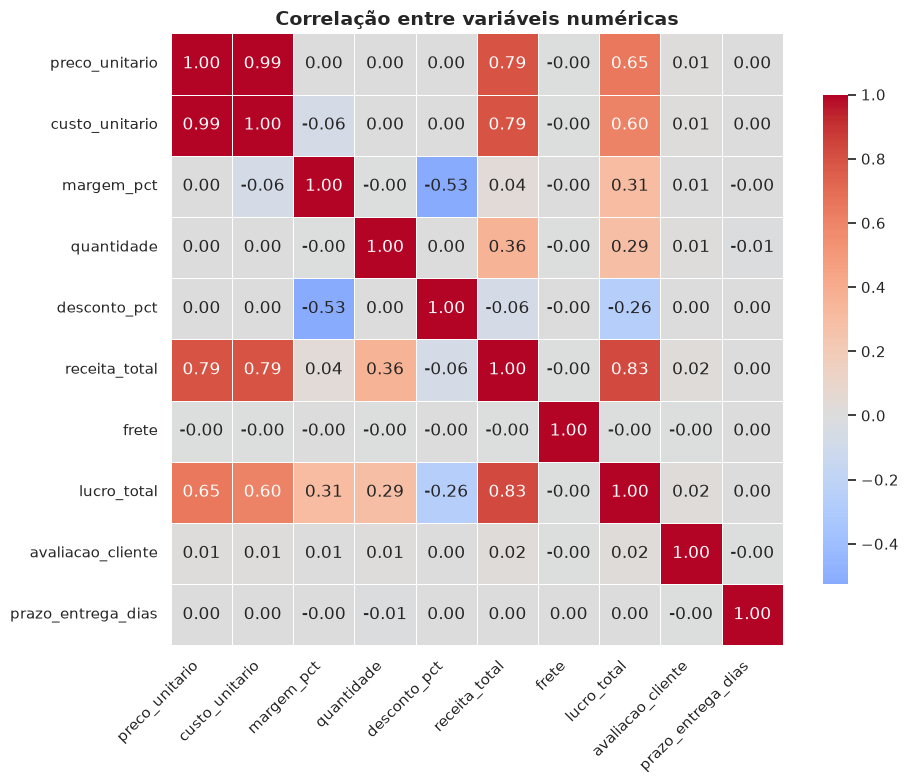

In [ ]:
colunas_num = ["preco_unitario", "custo_unitario", "margem_pct", "quantidade",
               "desconto_pct", "receita_total", "frete", "lucro_total",
               "avaliacao_cliente", "prazo_entrega_dias"]
corr = df[colunas_num].corr()

plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                 square=True, linewidths=.5, cbar_kws={"shrink": .8})
ax.set_title("Correlação entre variáveis numéricas", fontsize=14, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretação:** `preco_unitario` e `custo_unitario` sao **fortemente
correlacionados** (produtos mais caros custam mais para a empresa). `receita_total`
se relaciona positivamente com preco e quantidade, como esperado. Já `desconto_pct`
e `avaliacao_cliente` tem correlação fraca com as demais variáveis.

## Conclusão final

Analisando as vendas no Brasil ao longo dos tres entregaveis:

- **NumPy** mostrou que, apesar de uma receita media saudavel, uma fatia relevante das
  vendas da prejuizo — muitas vezes ligada a descontos altos.
- **Pandas** exigiu limpeza real (datas, cidades/canais padronizados, faltantes tratados)
  e revelou que **Eletronicos** e o **Sudeste** concentram receita e lucro.
- **Seaborn** confirmou visualmente esses padroes: concentracao de receita em poucas
  categorias, sazonalidade mensal, ausencia de relacao simples entre desconto e receita,
  e a forte correlacao entre preco e custo.

No geral, o negocio e **concentrado** (poucas categorias/regiões puxam o resultado) e
**sensivel a descontos**, que devem ser usados com cuidado para não comprometer a margem.